# Daniel Alejandro Rincón Valencia

Lo primero que se debe de realizar es importar las librerias que se usarán durante el desarrollo

In [1]:
import pandas as pd 
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

Se debe de cargar el df que se usara, en este caso estaba en formato xlsx y se convirtio a formato csv para una mayor facilidad

In [2]:
df = pd.read_csv('Salarios.csv')

In [6]:
df.shape

(29170, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29170 entries, 0 to 29169
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29170 non-null  int64 
 1   education-num   29170 non-null  int64 
 2   marital-status  29170 non-null  object
 3   relationship    29170 non-null  object
 4   race            29170 non-null  object
 5   sex             29170 non-null  object
 6   capital-gain    29170 non-null  int64 
 7   capital-loss    29170 non-null  int64 
 8   hours-per-week  29170 non-null  int64 
 9   native-country  29170 non-null  object
 10  salary          29170 non-null  object
dtypes: int64(5), object(6)
memory usage: 2.4+ MB


# METADATOS

age: Discreta

education-num: Discreto, ordinal 

marital-status: Nominal, politomico

relationship: Nominal, politomico

race: Nominal, politomico

sex: Nominal, dicotomico

capital-gain: continuo

capital-loss: continuo

hours-per-week: continuo

native-country: Nominal, politomica

salary: (variable objetivo) 


In [4]:
df.head(25)

,age,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,13,Never-married,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,13,Married-civ-spouse,Husband,White,Male,0,0,13,United-States,<=50K
2,38,9,Divorced,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,7,Married-civ-spouse,Husband,Black,Male,0,0,40,United-States,<=50K
4,37,14,Married-civ-spouse,Wife,White,Female,0,0,40,United-States,<=50K
5,52,9,Married-civ-spouse,Husband,White,Male,0,0,45,United-States,>50K
6,31,14,Never-married,Not-in-family,White,Female,14084,0,50,United-States,>50K
7,42,13,Married-civ-spouse,Husband,White,Male,5178,0,40,United-States,>50K
8,37,10,Married-civ-spouse,Husband,Black,Male,0,0,80,United-States,>50K
9,23,13,Never-married,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
df.columns

Index(['age', 'education-num', 'marital-status', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'salary'],
      dtype='object')

# Análisis de columnas

NO se eliminará ninguna columna, ya todas son relevantes y serán necesarias para realizar el analisis en base a la variable objetivo.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29170 entries, 0 to 29169
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29170 non-null  int64 
 1   education-num   29170 non-null  int64 
 2   marital-status  29170 non-null  object
 3   relationship    29170 non-null  object
 4   race            29170 non-null  object
 5   sex             29170 non-null  object
 6   capital-gain    29170 non-null  int64 
 7   capital-loss    29170 non-null  int64 
 8   hours-per-week  29170 non-null  int64 
 9   native-country  29170 non-null  object
 10  salary          29170 non-null  object
dtypes: int64(5), object(6)
memory usage: 2.4+ MB


In [9]:
df.isnull().sum().sort_values(ascending=False)

age               0
education-num     0
marital-status    0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

Se analiza por medio del df.info() que no haya ningun dato faltante.
Para este ejercicio se evidencia que todas las variables cuentan con la cantidad de datos que es 29170, por lo tanto no debemos de rellenar, eliminar o promediar para completar datos faltantes.

Despues de realizar el analisis sobre la cantidad de datos faltantes, el analisis de los metadatos para ver si las columnas son relevantes, se va a generar la estadistica descriptiva del df.

In [10]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,29170.000000,29170.000000,29170.000000,29170.000000,29170.000000
mean,38.655674,10.169455,1089.229928,88.510593,40.447755
std,13.722408,2.394966,7381.898528,405.681709,12.417203
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# Análisis estadística descriptiva

A primera vista se observa que 'capital-gain' y 'capital-loss' cuentan con una gran desviacion estandar, lo que indica que hay una gran variabilidad en los datos de estas columnas.

Ademas, se observa que 'education-num' y 'hours-per-week' tienen una desviacion estandar relativamente baja, lo que indica que los datos en estas columnas estan mas concentrados alrededor de la media.

En la variable 'age' se observa que no hay datos atipicos, ya que la edad minima es 17 y la edad maxima es 90, lo cual pueden representar datos comunes.

El perfil que puede llegar a ser mas comun es una persona de aproximadamente 38 años, con un nivel educativo 10; teniendo en cuenta que el nivel educativo el minimo es 1 y el maximo es 16 se puede inferir que cuenta con un nivel educativo aproximadamente un poco mayor al titulo de bachiller.

Los cuartiles de 'capital-gain' y ' 'capital-loss' son 0 porque posiblemente la mayoria de los registros es 0 en esas columnas



In [22]:
print("La cantidad de 0 en la variable capital-gain es:", (df['capital-gain'] == 0).sum())

La cantidad de 0 en la variable capital-gain es: 26699


In [19]:
print("La cantidad de 0 en la variable capital-loss es:", (df['capital-loss'] == 0).sum())

La cantidad de 0 en la variable capital-loss es: 27791


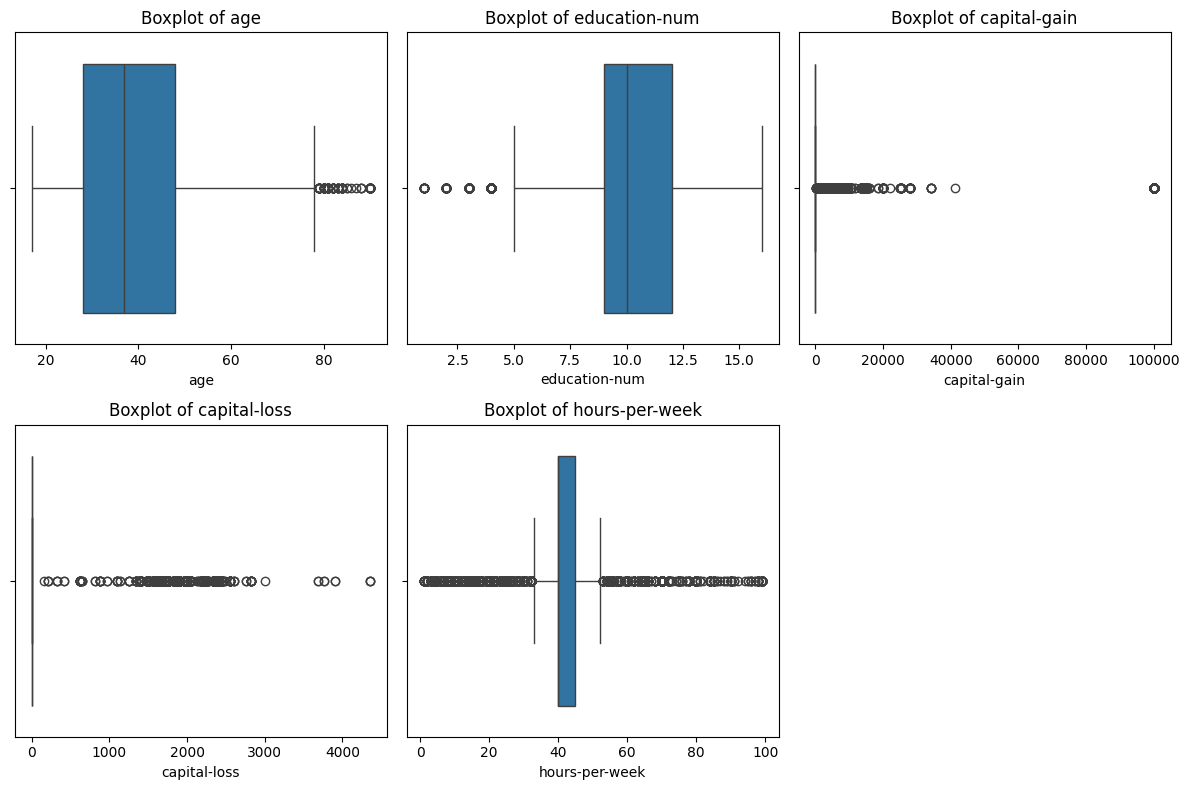

In [14]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.xlabel(col)

# Análisis boxplots

Age: La mayoria de las edades esta concentradas entre 28 y 48 años, no se observan valores atipicos extremos, indicando una distribucion norma de edades.

education-num: La mayoria de valores se agrupan entre 9 y 12, indicando que las personas suelen tener un nivel educativo medio, se encuentran valores atipicos muy bajos, pero esto puede llegar a ser normal ya que no todas las personas logran terminar la educacion basica.

capital-gain: EL boxplot muestra que una gran cantidad de datos estan entre 0 y 20000, se evidencian valores atipicos muy altos pero se consideran normales ya que una persona puede tener la capacidad de tener esa ganancia capital, o incluso mucho mas.

capital-loss: El boxplot muestra que una gran cantidad de datos en 0

hours-per-week: Se observan valores atipicos bajos que pueden llegar a ser comunes, ya que pueden haber trabajos de medio tiempo e incluso de un solo dia, y valores atipicos altos que no suelen ser tan comunes a la realidad 

In [25]:
print("La cantidad de 0 en la variable hours-per-week es:", (df['hours-per-week'] == 0).sum())

La cantidad de 0 en la variable hours-per-week es: 0


# Gráficos en relación a variable objetivo 'salary'

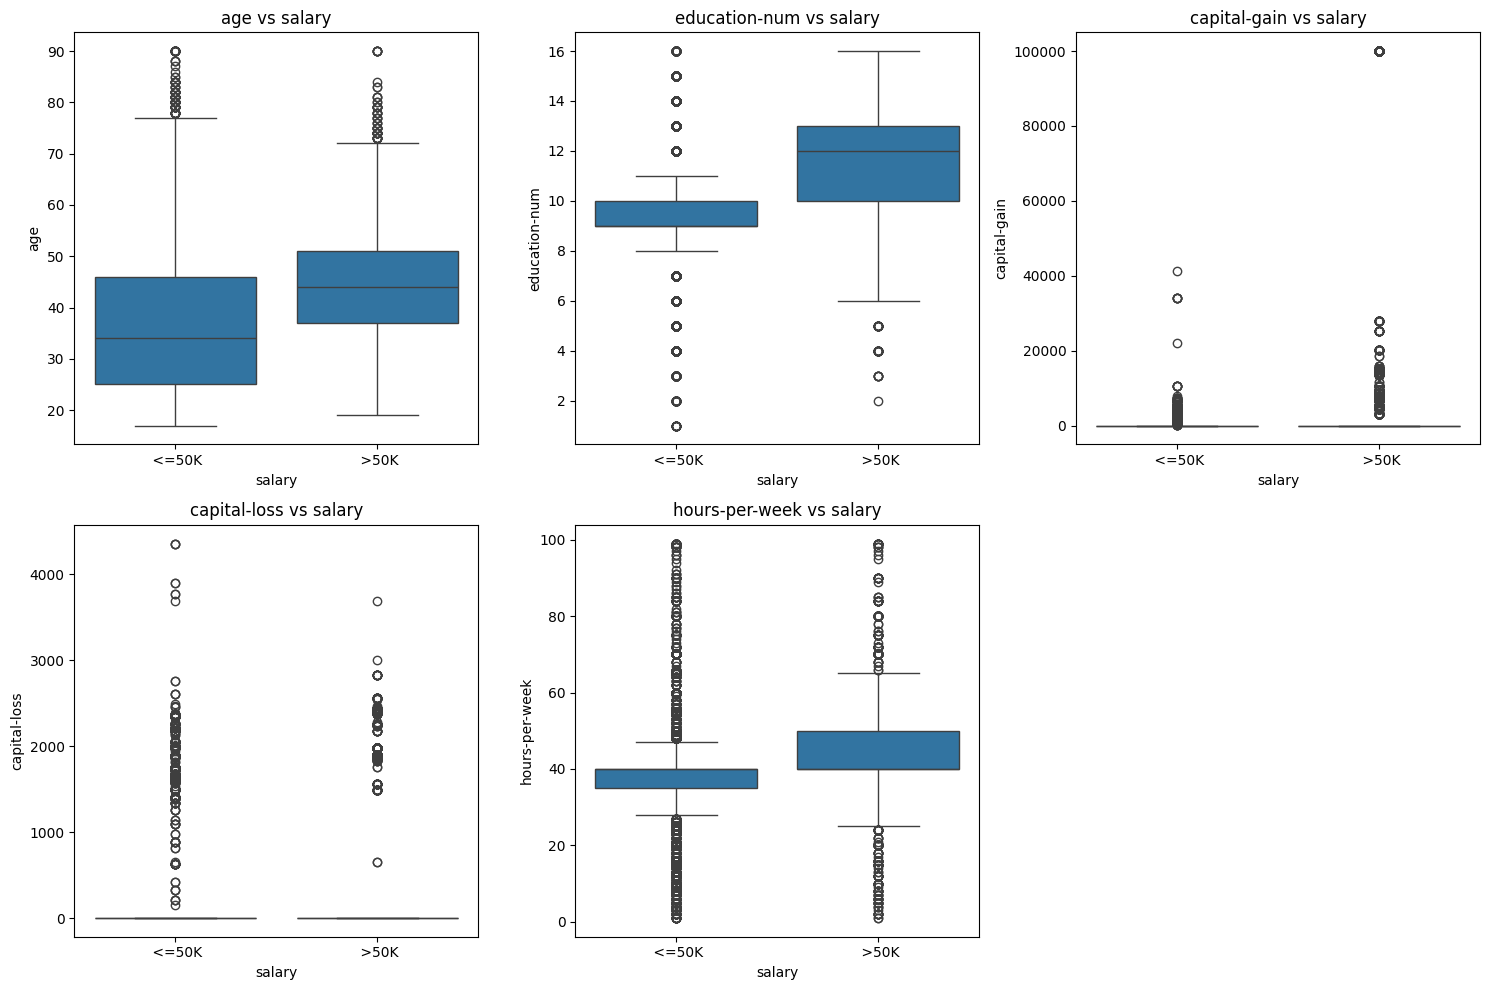

In [26]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='salary', y=col, data=df)
    plt.title(f'{col} vs salary')
plt.tight_layout()
plt.show()

variables numericas vs salary

Usando los graficos tipos boxplot, ayuda a comparar la distribucion de las diferentes variables numericas entre la variable objetivo, facilitando a identificar las diferencias de la mediana y los valores atipicos que pueden tener en ese rango de salarios.

age vs salary: Puede ayudar a identificar si por ejemplo los de mayor edad pueden tener un grupo salarial mas alto.

education-num vs salary: Ayuda a identificar si el nivel educativo esta relacionado con el salario, indicando que entre mayor nivel educativo mayor puede llegar a ser el salario.

hours-per-week: Analiza si se trabaja mas horas a la semana pueden llegar a tener salarios mas altos.

-----------------------------------------------------------------------------------------



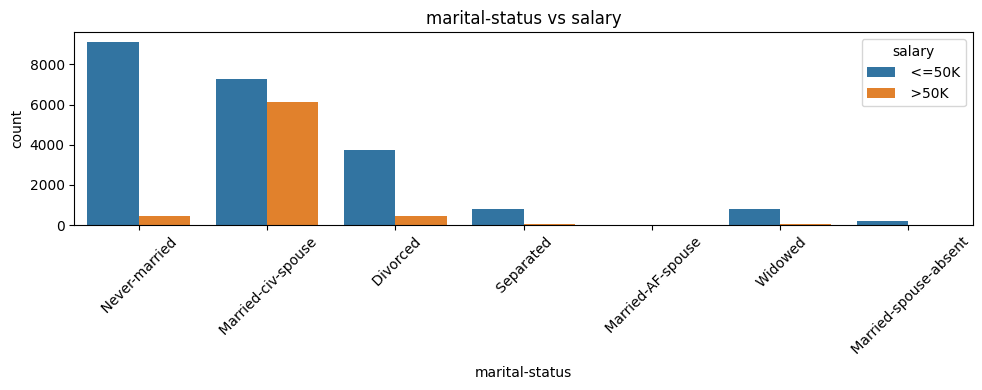

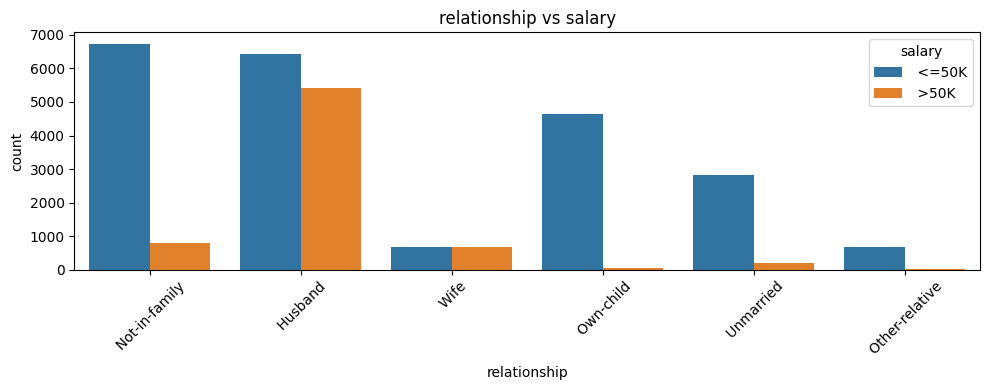

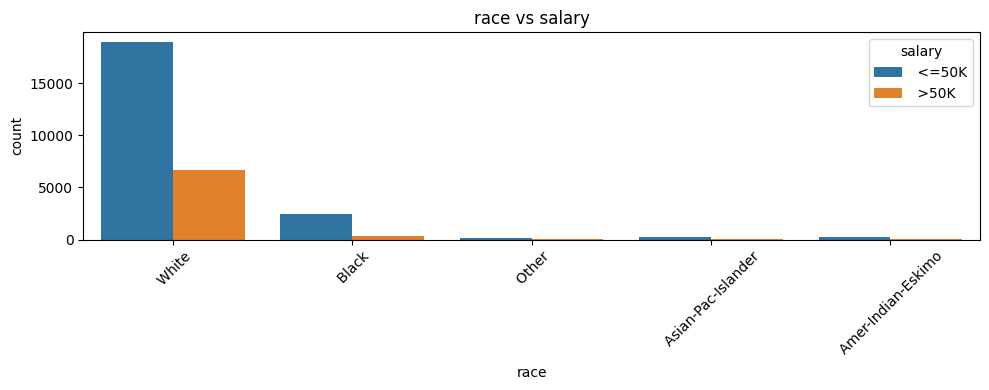

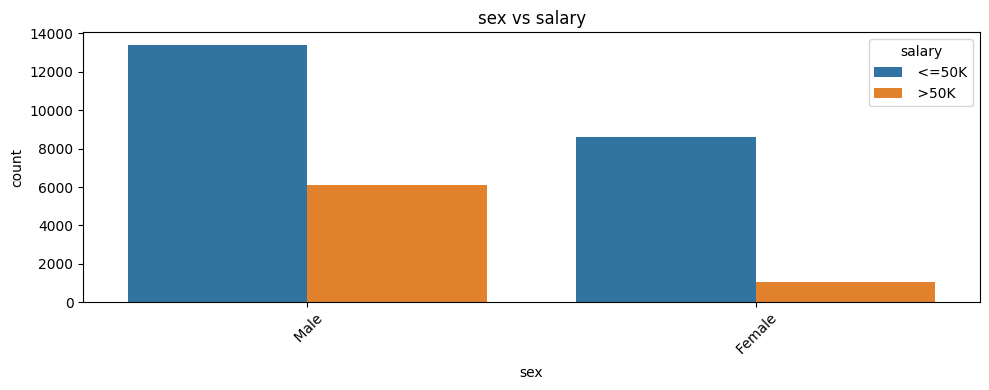

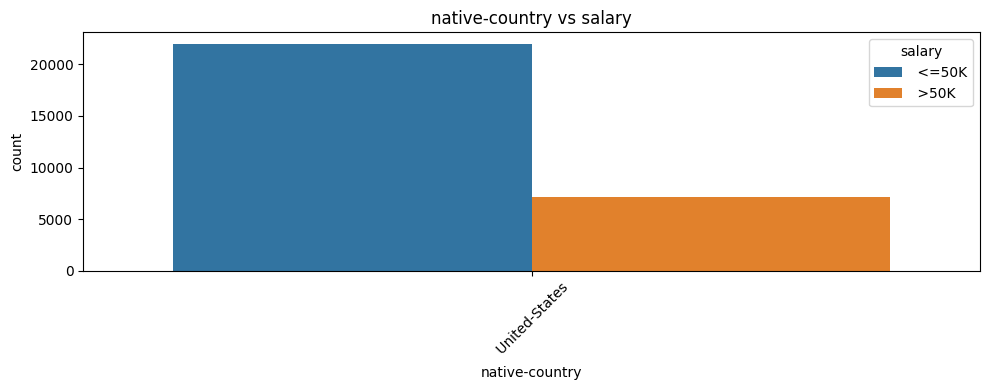

In [27]:
cat_cols = ['marital-status', 'relationship', 'race', 'sex', 'native-country']
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, hue='salary', data=df)
    plt.title(f'{col} vs salary')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

variables categoricas vs salary

Usando los graficos countplot ayuda a mostrar la frecuencia de cada categoria en relacion al rango del salario

------------------------------------------------------------------------------

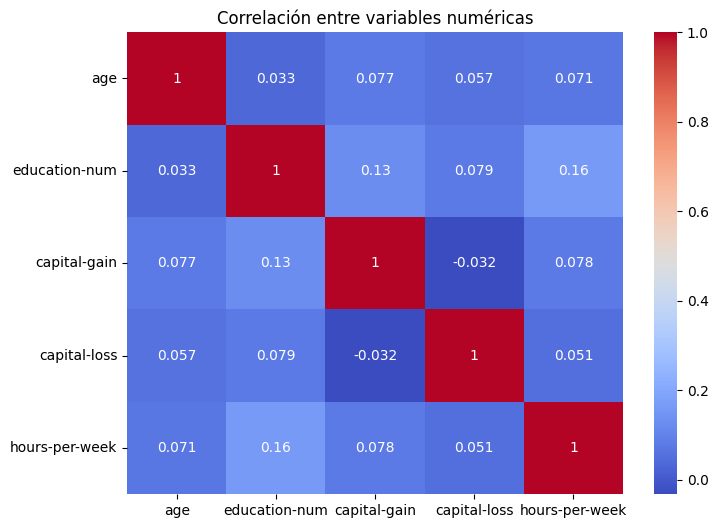

In [30]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

El mapa de calor ayuda a visualizar la relación lineal entre las variables de tipo numerico, facilitando identificar cuales variables pueden llegar a estar mas correlacionadas.

Todas las relaciones a excepcion de 2 presentan correlacion positiva indicando que pueden ser directamente proporcionales, pero no cuentan con una correlacion muy fuerte, significando que cada variable aporta informacion diferente para el analisis.

capital-gain y capital-loss: La correlacion entre estas dos variables es baja, lo que significa que no suelen aumentar o disminuir juntas, siendo estas variables con las unica correlacion negativa.



# Conclusión final 

El analisis gráfico muestra que variables como age, education-num y hours-per-week presentan diferencias un poco claras entre los grupos salariales que son (<=50K y >50K), demostrando que a mayor edad, mayor nivel educativo y mayor cantidad de horas trabajadas, puede ser un poco mas probable pertenecer al grupo de mayor salario. Las variables de capital-gain y capital-loss tienen muchos valores en cero, pero los valores altos suelen asociarse con los salarios mayores.  En general, no hay una sola variable que determine el salario gran parte, sino que es el resultado de las diferentes variables trabajadas dentro del df.